# 🔵 Sinais complexos e I/Q — o que é o CSI
por: **Iury Coelho**

Até aqui, nossos sinais foram **reais** (um número por instante). Mas todo
sistema de rádio — e o CSI que o RuView usa — trabalha com sinais **complexos**:
cada amostra é um número $z = I + jQ$, com uma parte **I** (*in-phase*) e uma
parte **Q** (*quadrature*).

Por quê? Porque um número complexo guarda **duas** informações de uma vez:
**amplitude** $|z|$ e **fase** $\angle z$. E é na **fase** que mora o segredo do
sensoriamento: um movimento minúsculo do alvo (o peito respirando) quase não
muda a amplitude, mas **gira a fase** de um jeito mensurável.

Este é o "lado rádio" da nossa trilha rumo ao RuView.

#### Conteúdo
* [1. Fasores: senoides como números complexos](#1)
* [2. I e Q: as duas componentes](#2)
* [3. Amplitude e fase](#3)
* [4. A fase revela o movimento](#4)
* [5. Por que a fase é tão sensível](#5)
* [6. Da simulação ao mundo real](#6)
* [7. Exercício](#7)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def espectro(x, fs):
    X = np.abs(np.fft.rfft(x)) / len(x) * 2
    f = np.fft.rfftfreq(len(x), 1/fs)
    return f, X

<a id="1"></a>
## 1. Fasores: senoides como números complexos

A identidade de Euler $e^{j\theta} = \cos\theta + j\,\sin\theta$ diz que um número
complexo de módulo 1 é um **ponto no círculo unitário**, no ângulo $\theta$. Uma
senoide complexa $z(t) = e^{j 2\pi f t}$ é então um ponto **girando** no plano —
um **fasor**. Sua parte real é um cosseno; a imaginária, um seno.

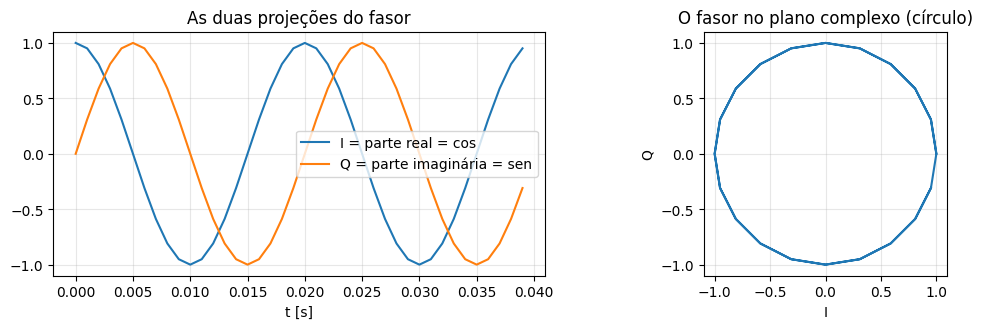

In [2]:
fs = 1000
t = np.arange(0, 0.04, 1/fs)
f = 50
z = np.exp(1j * 2*np.pi * f * t)      # fasor girando

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, z.real, label="I = parte real = cos")
a1.plot(t, z.imag, label="Q = parte imaginária = sen")
a1.set_title("As duas projeções do fasor"); a1.set_xlabel("t [s]"); a1.legend()
a2.plot(z.real, z.imag); a2.set_aspect("equal")
a2.set_title("O fasor no plano complexo (círculo)")
a2.set_xlabel("I"); a2.set_ylabel("Q")
plt.tight_layout(); plt.show()

<a id="2"></a>
## 2. I e Q: as duas componentes

Um receptor de rádio mede $I$ e $Q$ separadamente. Juntos eles formam o sinal
complexo $z = I + jQ$. A vantagem: com I **e** Q dá para saber não só *quanto* o
sinal vale, mas em que **fase** ele está — algo impossível com um sinal real
sozinho (que confunde, por exemplo, $+90°$ com $-90°$).

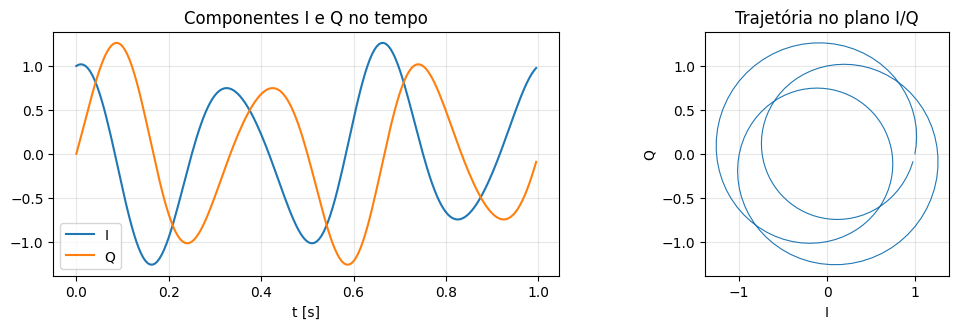

In [3]:
# um sinal complexo com amplitude e fase que variam
t = np.arange(0, 1, 1/200)
amp = 1 + 0.3*np.sin(2*np.pi*2*t)
fase = 2*np.pi*3*t
z = amp * np.exp(1j*fase)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, z.real, label="I"); a1.plot(t, z.imag, label="Q")
a1.set_title("Componentes I e Q no tempo"); a1.set_xlabel("t [s]"); a1.legend()
a2.plot(z.real, z.imag, lw=0.8); a2.set_aspect("equal")
a2.set_title("Trajetória no plano I/Q"); a2.set_xlabel("I"); a2.set_ylabel("Q")
plt.tight_layout(); plt.show()

<a id="3"></a>
## 3. Amplitude e fase

Do número complexo extraímos **amplitude** $|z| = \sqrt{I^2 + Q^2}$ e **fase**
$\angle z = \operatorname{atan2}(Q, I)$. Como a fase vive em $[-\pi, \pi]$, ela
"dá voltas"; `np.unwrap` desfaz esses saltos para revelar a evolução contínua.

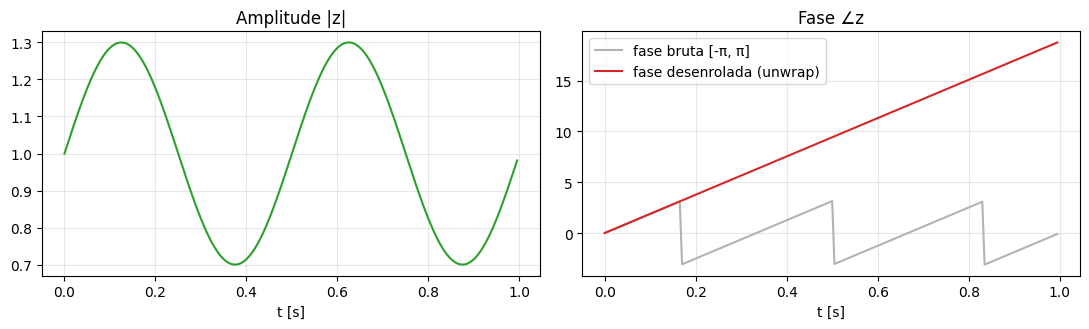

In [4]:
amplitude = np.abs(z)
fase_bruta = np.angle(z)
fase_cont = np.unwrap(fase_bruta)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, amplitude, "C2"); a1.set_title("Amplitude |z|"); a1.set_xlabel("t [s]")
a2.plot(t, fase_bruta, "0.7", label="fase bruta [-π, π]")
a2.plot(t, fase_cont, "C3", label="fase desenrolada (unwrap)")
a2.set_title("Fase ∠z"); a2.set_xlabel("t [s]"); a2.legend()
plt.tight_layout(); plt.show()

<a id="4"></a>
## 4. A fase revela o movimento

Agora o coração do sensoriamento. Quando uma onda de rádio percorre uma distância
$d$ até um alvo e volta, ela acumula uma **fase** proporcional ao caminho:
$$ \phi = -\frac{2\pi \cdot 2d}{\lambda}, $$
onde $\lambda$ é o comprimento de onda. Se o alvo se move (o peito ao respirar),
$d$ muda e a **fase do CSI oscila** — mesmo que a amplitude quase não mude.

Vamos simular o CSI de WiFi (2,4 GHz, $\lambda \approx 12{,}5$ cm) refletido por
um peito que sobe e desce **5 mm** a 18 respirações/min.

comprimento de onda: 12.5 cm


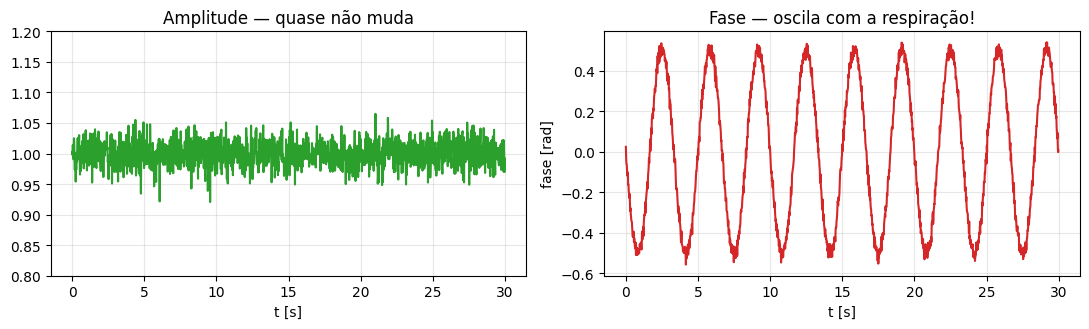

In [5]:
c = 3e8
fc = 2.4e9
lam = c / fc                 # ~0.125 m
print(f"comprimento de onda: {lam*100:.1f} cm")

fs = 50.0
dur = 30.0
t = np.arange(0, dur, 1/fs)
rng = np.random.default_rng(0)

f_resp = 0.30                # 18 respiracoes/min
desloc = 0.005 * np.sin(2*np.pi*f_resp*t)        # peito: +-5 mm
csi = np.exp(-1j * 2*np.pi * 2*desloc / lam)     # CSI complexo (amplitude ~1)
csi += 0.02 * (rng.standard_normal(len(t)) + 1j*rng.standard_normal(len(t)))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(t, np.abs(csi), "C2"); a1.set_ylim(0.8, 1.2)
a1.set_title("Amplitude — quase não muda"); a1.set_xlabel("t [s]")
a2.plot(t, np.unwrap(np.angle(csi)), "C3")
a2.set_title("Fase — oscila com a respiração!"); a2.set_xlabel("t [s]")
a2.set_ylabel("fase [rad]")
plt.tight_layout(); plt.show()

A amplitude é praticamente plana, mas a **fase** desenha a respiração. Extraindo
a frequência dessa fase (com a FFT do notebook 04), recuperamos o ritmo
respiratório — **só a partir da fase do sinal complexo**.

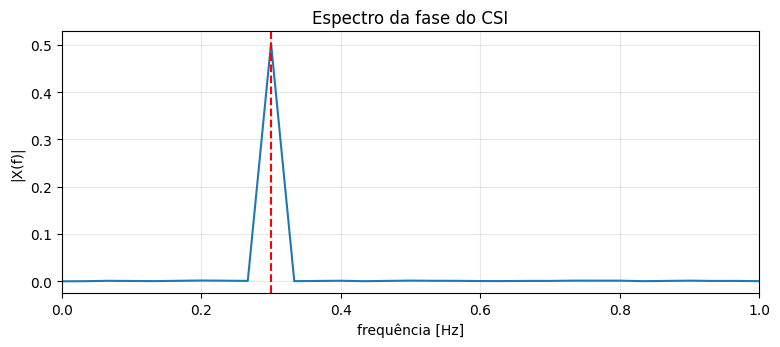

Respiração estimada a partir da fase: 18.0 por minuto


In [6]:
fase = np.unwrap(np.angle(csi))
fase = fase - fase.mean()                # remove o nivel medio
f, X = espectro(fase, fs)
faixa = (f >= 0.1) & (f <= 0.6)
rpm = f[faixa][np.argmax(X[faixa])] * 60

plt.plot(f, X); plt.xlim(0, 1.0)
plt.axvline(rpm/60, color="r", ls="--")
plt.title("Espectro da fase do CSI"); plt.xlabel("frequência [Hz]"); plt.ylabel("|X(f)|")
plt.show()
print(f"Respiração estimada a partir da fase: {rpm:.1f} por minuto")

<a id="5"></a>
## 5. Por que a fase é tão sensível

A fase completa uma volta inteira ($2\pi$) a cada **meio comprimento de onda** de
movimento (ida e volta). Para WiFi a 2,4 GHz, isso é só ~6,25 cm. Logo:

| Movimento do alvo | Variação de fase |
|---|---|
| 6,25 cm | 360° (uma volta) |
| 5 mm (respiração) | ~29° — bem mensurável |
| 0,5 mm (batimento) | ~3° — detectável com pouco ruído |

É por isso que sistemas de RF "enxergam" movimentos sub-centimétricos: eles olham
a **fase**, não a amplitude. A amplitude diz "tem algo ali"; a fase diz "e está
se movendo *assim*".

In [7]:
movimentos_mm = np.array([62.5, 5.0, 0.5, 0.1])
graus = 360 * (2*movimentos_mm/1000) / lam
for m, g in zip(movimentos_mm, graus):
    print(f"{m:6.1f} mm de movimento  ->  {g:7.1f}° de variação de fase")

  62.5 mm de movimento  ->    360.0° de variação de fase
   5.0 mm de movimento  ->     28.8° de variação de fase
   0.5 mm de movimento  ->      2.9° de variação de fase
   0.1 mm de movimento  ->      0.6° de variação de fase


<a id="6"></a>
## 6. Da simulação ao mundo real

No RuView e afins, o CSI complexo chega de **várias subportadoras e antenas**, com
ruído, múltiplos caminhos e saltos de fase do hardware (que exigem calibração).
Mas a ideia central é esta: **a fase do sinal complexo codifica o movimento**, e
é dela que se extraem respiração, batimento e gestos.

> ⚠️ Didático. Sistemas reais lidam com ruído de fase, *clutter* e ambiguidades
> que omitimos aqui.

Você acabou de ver *por que* o CSI é complexo — o conceito que destrava todo o
resto da trilha. 🚀

<a id="7"></a>
## 7. Exercício

__Exercício__ — Troque a frequência do rádio `fc` para **5 GHz** (WiFi 5 GHz) e
rode a seção 4 de novo. Como muda o comprimento de onda? A mesma respiração de
5 mm produz **mais** ou **menos** variação de fase? Isso torna o sensing mais ou
menos sensível?

In [8]:
for fc_teste in [2.4e9, 5.0e9]:
    lam_t = c / fc_teste
    graus_resp = 360 * (2*0.005) / lam_t      # 5 mm de respiracao
    print(f"fc = {fc_teste/1e9:.1f} GHz  ->  λ = {lam_t*100:.2f} cm  ->  "
          f"respiração de 5 mm = {graus_resp:.1f}° de fase")

fc = 2.4 GHz  ->  λ = 12.50 cm  ->  respiração de 5 mm = 28.8° de fase
fc = 5.0 GHz  ->  λ = 6.00 cm  ->  respiração de 5 mm = 60.0° de fase


__Resposta__: em 5 GHz o comprimento de onda cai pela metade (~6 cm → ~3 cm), então
**a mesma respiração gira a fase quase o dobro** — frequências mais altas são
**mais sensíveis** a pequenos movimentos. (O preço é menor alcance e mais
sensibilidade a ruído; é um compromisso de projeto.)

---
<br>[⬆ volte ao topo](#Conteúdo)